In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [9]:
# define state

class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    category: str

In [4]:
def calculateBMI(State: BMIState) -> BMIState:
    weight = State['weight']
    height = State['height']
    bmi = weight / (height ** 2)

    State['bmi'] = round(bmi, 2)
    return State

In [8]:
def get_category(State: BMIState) -> BMIState:
    bmi = State['bmi']
    if bmi < 18.5:
        category = 'Underweight'
    elif 18.5 <= bmi < 25:
        category = 'Normal weight'
    elif 25 <= bmi < 30:
        category = 'Overweight'
    else:
        category = 'Obesity'

    State['category'] = category
    return State

In [10]:
# define graph

graph = StateGraph(BMIState)

# add nodes to graph

graph.add_node('calculate_bmi', calculateBMI)
graph.add_node('get_category', get_category)

# add edges to graph

graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'get_category')
graph.add_edge('get_category', END)

# compile graph

workflow = graph.compile()

In [12]:
# execute graph
input_state = {'weight': 70, 'height': 1.75}

output_state = workflow.invoke(input_state)

print(output_state)

{'weight': 70, 'height': 1.75, 'bmi': 22.86, 'category': 'Normal weight'}


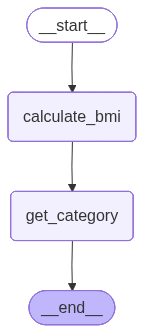

In [11]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())